First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    80       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset (rows, columns):
(15, 9)

Data types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:

            

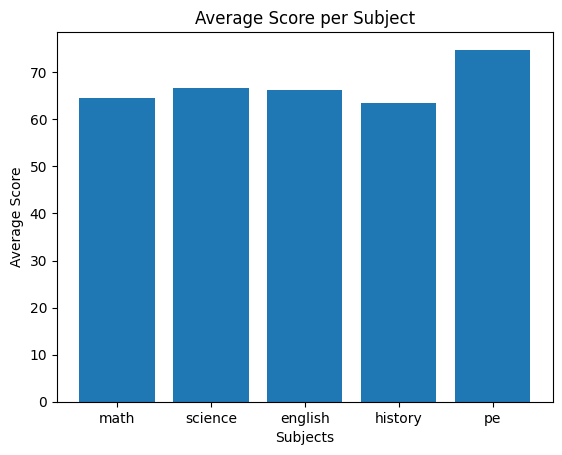

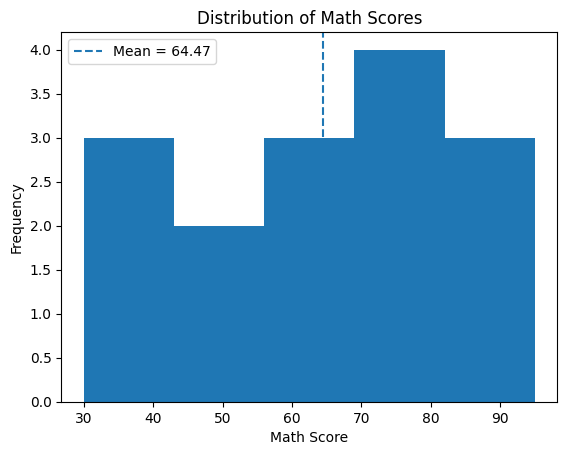

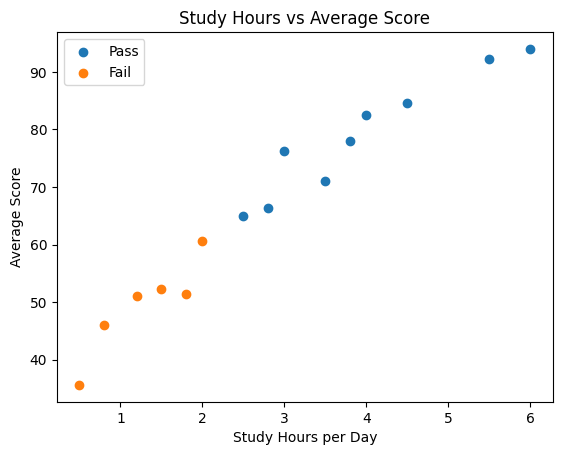

/tmp/ipykernel_3032/1352996779.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


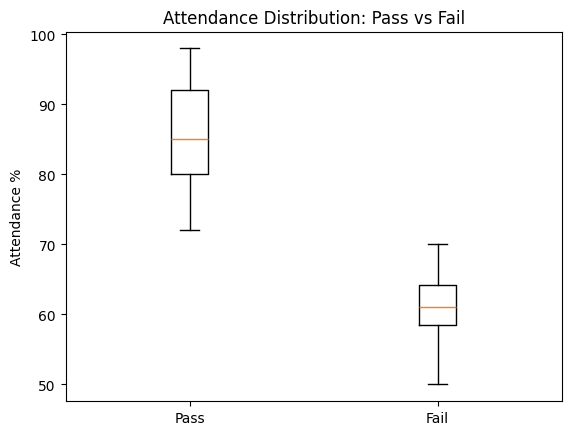

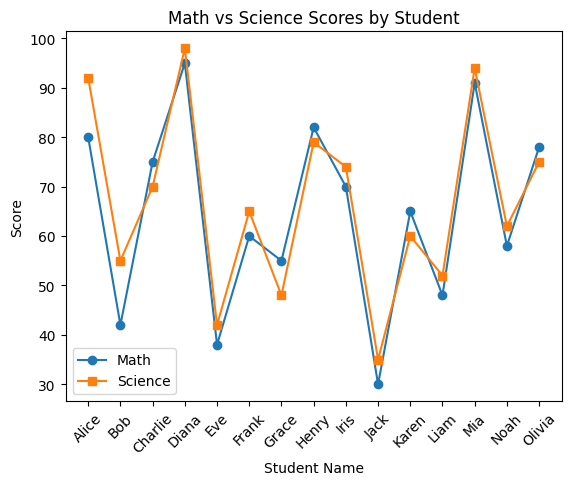


      TASK 3 - Data Visualization with Seaborn


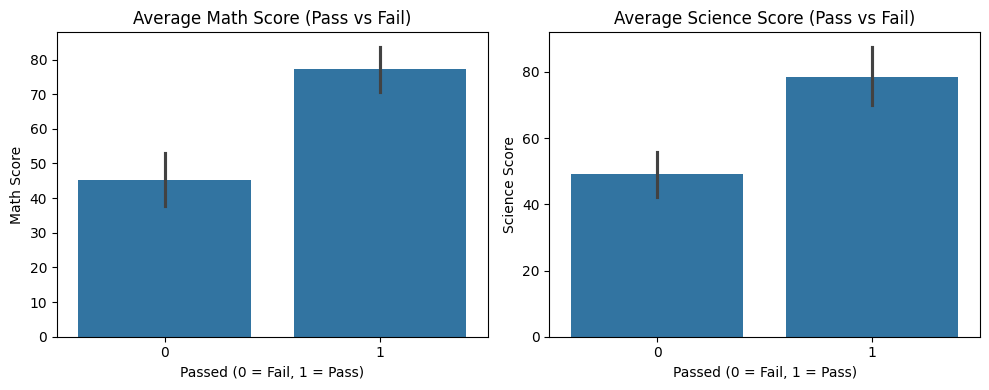

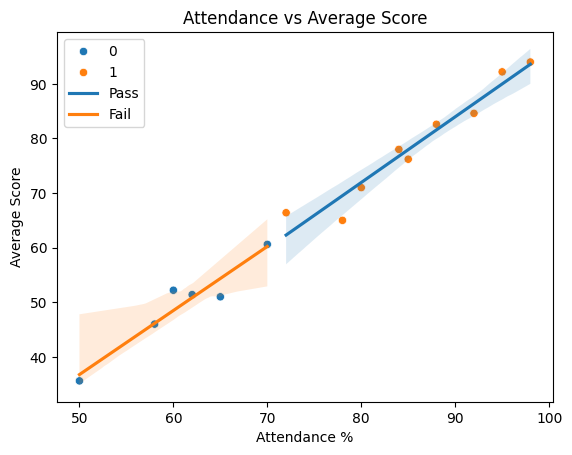


    TASK 4 - Machine Learning with scikit-learn
Training Accuracy: 1.00

Test Accuracy: 1.00

Test Predictions:
Jack → Actual: 0, Predicted: 0 → ✅ Correct
Liam → Actual: 0, Predicted: 0 → ✅ Correct
Alice → Actual: 1, Predicted: 1 → ✅ Correct

Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


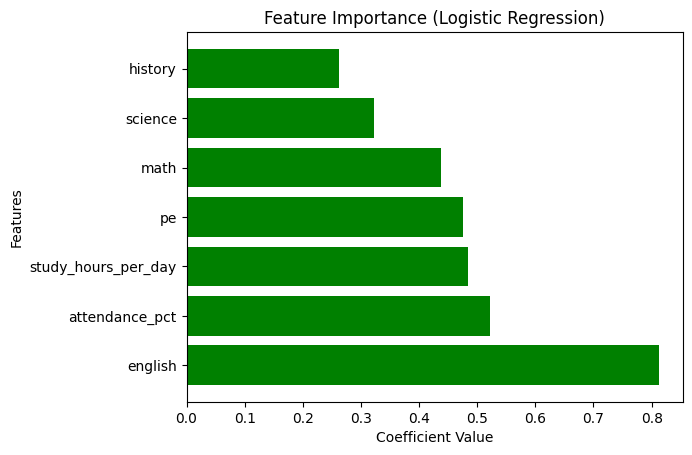


New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [32]:
# ============================================================
# Assignment - Part 4: Data Visualization & Machine Learning
# Theme: Student Performance Analysis & Prediction
# # ============================================================

# ============================================================
# TASK 1 - Data Exploration with Pandas (5 marks)
# ============================================================

import pandas as pd

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("students.csv")

# -------------------------------
# 1. First 5 rows
# -------------------------------
print("First 5 rows:\n")
print(df.head())


# -------------------------------
# 2. Shape and data types
# -------------------------------
print("\nShape of dataset (rows, columns):")
print(df.shape)

print("\nData types:\n")
print(df.dtypes)


# -------------------------------
# 3. Summary statistics
# -------------------------------
print("\nSummary statistics:\n")
print(df.describe())


# -------------------------------
# 4. Pass vs Fail count
# -------------------------------
print("\nPass/Fail count:")
print(df["passed"].value_counts())


# -------------------------------
# 5. Average scores (Pass vs Fail)
# -------------------------------

subject_cols = ['math', 'science', 'english', 'history', 'pe']

# average for passing students
pass_avg = df[df["passed"] == 1][subject_cols].mean()

# average for failing students
fail_avg = df[df["passed"] == 0][subject_cols].mean()

print("\nAverage scores (Passing Students):")
print(pass_avg)

print("\nAverage scores (Failing Students):")
print(fail_avg)


# -------------------------------
# 6. Student with highest average
# -------------------------------

# create a temporary average column
df["avg_score"] = df[subject_cols].mean(axis=1)

# find row with highest average
top_student = df.loc[df["avg_score"].idxmax()]

print("\nTop student based on average:")
print(top_student[["name", "avg_score"]])


# ============================================================
# TASK 2 - Data Visualization with Matplotlib
# ============================================================

print("\n" + "=" * 55)
print("   TASK 2 - Data Visualization with Matplotlib")
print("=" * 55)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# ---- Plot 1: Bar Chart - Average score per subject -

# calculate average per subject
avg_scores = df[subject_cols].mean()

plt.figure()

plt.bar(avg_scores.index, avg_scores.values)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

# ---- Plot 2: Histogram - Distribution of math scores ----
plt.figure()

plt.hist(df["math"], bins=5)

# mean line
mean_math = df["math"].mean()
plt.axvline(mean_math, linestyle="dashed", label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

# ---- Plot 3: Scatter Plot - Study hours vs Avg score (coloured by pass/fail) ----
plt.figure()

# separate pass and fail
pass_data = df[df["passed"] == 1]
fail_data = df[df["passed"] == 0]

plt.scatter(pass_data["study_hours_per_day"], pass_data["avg_score"], label="Pass")
plt.scatter(fail_data["study_hours_per_day"], fail_data["avg_score"], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

# ---- Plot 4: Box Plot - Attendance % for Pass vs Fail ----
plt.figure()

pass_attendance = df[df["passed"] == 1]["attendance_pct"].tolist()
fail_attendance = df[df["passed"] == 0]["attendance_pct"].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

# ---- Plot 5: Line Plot - Math and Science scores for each student ----
plt.figure()

plt.plot(df["name"], df["math"], marker="o", label="Math")
plt.plot(df["name"], df["science"], marker="s", label="Science")

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

# ============================================================
# TASK 3 - Data Visualization with Seaborn
# ============================================================

print("\n" + "=" * 55)
print("      TASK 3 - Data Visualization with Seaborn")
print("=" * 55)

!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# ---- Plot 6: Seaborn Bar Plot - Math and Science avg scores split by Pass/Fail ----
plt.figure(figsize=(10, 4))

# subplot 1 → math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Math Score")

# subplot 2 → science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("seaborn_bar.png")
plt.show()

# ---- Plot 7: Seaborn Scatter/Regplot - Attendance vs Avg Score ----
plt.figure()

# scatter plot with hue (color by pass/fail)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# regression line for passing students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# regression line for failing students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("seaborn_scatter.png")
plt.show()

# Seaborn vs Matplotlib comparison comment:
# Seaborn felt easier for creating clean and visually appealing plots compared to Matplotlib.
# The bar plots required less manual work, especially for grouping by categories like Pass/Fail.
# However, for full control and customization, Matplotlib still feels more flexible.

# ============================================================
# TASK 4 - Machine Learning with scikit-learn
# ============================================================

print("\n" + "=" * 55)
print("    TASK 4 - Machine Learning with scikit-learn")
print("=" * 55)

!pip install scikit-learn

# ---- Step 1: Prepare Data ----
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# load data
df = pd.read_csv("students.csv")

# features (excluding name)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]

# target
y = df['passed']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale features (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---- Step 2: Train the Model ----

# create model
model = LogisticRegression()

# train model
model.fit(X_train_scaled, y_train)

# training accuracy
train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc:.2f}")

# ---- Step 3: Evaluate the Model ----
# predictions
y_pred = model.predict(X_test_scaled)

# test accuracy
test_acc = model.score(X_test_scaled, y_test)

print(f"\nTest Accuracy: {test_acc:.2f}\n")

# print detailed results
print("Test Predictions:")

for i, pred in enumerate(y_pred):
    actual = y_test.iloc[i]
    name = df.loc[X_test.index[i], 'name']

    status = "✅ Correct" if pred == actual else "❌ Wrong"

    print(f"{name} → Actual: {actual}, Predicted: {pred} → {status}")

# ---- Step 4: Feature Importance ----

import matplotlib.pyplot as plt

# get coefficients
coefficients = model.coef_[0]

# pair with feature names
feature_importance = list(zip(feature_cols, coefficients))

# sort by absolute value (most important first)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")


# -------------------------------
# Plot coefficients
# -------------------------------

features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

# color based on sign
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()

plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("feature_importance.png")
plt.show()

# ---- Step 5: Predict for a new student ----
# new student data (same order as features)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# scale using same scaler
new_scaled = scaler.transform(new_student)

# prediction
prediction = model.predict(new_scaled)[0]

# probability
prob = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print(f"Prediction: {result}")
print(f"Probability (Fail, Pass): {prob}")
